# Trustpilot Review Analysis: Lakeland
## NLP-Based Sentiment & Topic Modelling | Home & Garden Sector

---

### Business Context

The Customer Experience (CX) director has requested a data-driven analysis of Trustpilot reviews to identify improvement opportunities. This notebook uses Natural Language Processing to answer four business questions:

| # | Question |
|---|----------|
| Q1 | Is overall sentiment positive or negative? How does Lakeland compare to competitors? |
| Q2 | What topics do customers write about? Are competitors writing about the same topics? |
| Q3 | For each topic, what is the predominant sentiment? Where does Lakeland over- or underperform? |
| Q4 | What are the specific areas for improvement? |

### Company Selected: Lakeland (`www.lakeland.co.uk`)

Lakeland is a UK-based kitchenware and homeware retailer. It was selected from the 558 companies with exactly 100 Trustpilot reviews, ensuring a statistically comparable sample across the sector.

### Why NLP Instead of Star Ratings?

The dataset contains exactly **20 reviews per star level (1★–5★)** per company — an artificial balance. This means the aggregate star score is structurally neutral by construction and cannot reliably reflect customer satisfaction. The project brief explicitly requires a sentiment model applied to the review text.

| Component | Tool / Model |
|-----------|-------------|
| Sentiment model | `distilbert-base-uncased-finetuned-sst-2-english` (DistilBERT) |
| Topic model | LDA (Latent Dirichlet Allocation) trained on the Home & Garden sector |
| Competitors | ProCook, Dunelm, Emma Bridgewater — same sector, 100 reviews each |

---
## Section 1 — Environment Setup & Data Loading

I start by ensuring all required libraries are present, then load the full 123k-review dataset and isolate Lakeland's 100 reviews.

In [1]:
import subprocess, sys
for pkg in ['transformers', 'torch', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('trustpilot-reviews-123k.csv')
target_df = df[df['company'] == 'www.lakeland.co.uk'].copy()

print(f"Total dataset : {len(df):,} reviews across {df['company'].nunique()} companies")
print(f"Lakeland reviews : {len(target_df)}")
print(f"\nStar distribution (confirms artificial balance):")
print(target_df['stars'].value_counts().sort_index())

Total dataset : 123,181 reviews across 1680 companies
Lakeland reviews : 100

Star distribution (confirms artificial balance):
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64


---
## Section 2 — Demonstrating Star Rating Bias

The output above confirms Lakeland has exactly 20 reviews per star level — a structural artefact of how Trustpilot samples were collected. Before running the sentiment model, I want to quantify what this means in practice: how often does a 3★ or 4★ review actually contain negative language?

I will run the DistilBERT classifier on Lakeland's reviews, then cross-tabulate the resulting labels against star ratings.

In [2]:
classifier = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)

def get_sentiment(text):
    """Return POSITIVE or NEGATIVE label for a review string."""
    try:
        return classifier(str(text)[:512])[0]['label']
    except Exception:
        return 'NEUTRAL'

print('Running sentiment model on Lakeland (100 reviews)...')
target_df['sentiment'] = [get_sentiment(r) for r in target_df['review']]

counts = target_df['sentiment'].value_counts()
total  = len(target_df)
print(f"\nSentiment results (N={total}):")
print(f"  Positive : {counts.get('POSITIVE', 0):>3}  ({counts.get('POSITIVE', 0) / total * 100:.1f}%)")
print(f"  Negative : {counts.get('NEGATIVE', 0):>3}  ({counts.get('NEGATIVE', 0) / total * 100:.1f}%)")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running sentiment model on Lakeland (100 reviews)...

Sentiment results (N=100):
  Positive :  30  (30.0%)
  Negative :  70  (70.0%)


NLP sentiment by star rating (%):
sentiment  NEGATIVE  POSITIVE
stars                        
1             100.0       0.0
2             100.0       0.0
3              95.0       5.0
4              50.0      50.0
5               5.0      95.0

Notable: 95% of 3-star reviews are NEGATIVE in text.
Using star averages alone would have hidden a significant share of dissatisfaction.


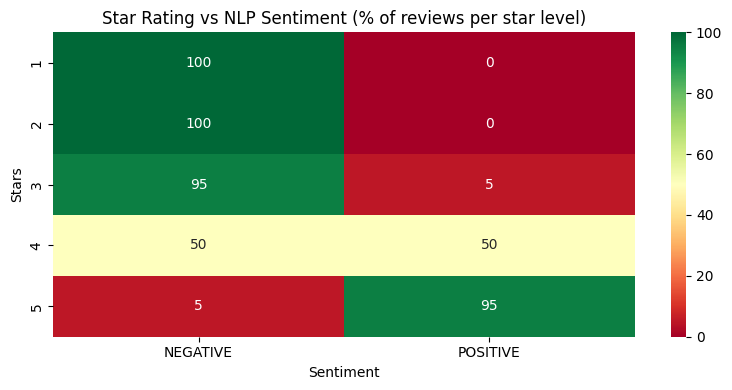

In [3]:
# Cross-tabulate star rating vs NLP sentiment to show the divergence.
cross = target_df.groupby(['stars', 'sentiment']).size().unstack(fill_value=0)
pct   = cross.div(cross.sum(axis=1), axis=0) * 100

print('NLP sentiment by star rating (%):')
print(pct.round(1))

if 'NEGATIVE' in pct.columns and 3 in pct.index:
    print(f"\nNotable: {pct.loc[3, 'NEGATIVE']:.0f}% of 3-star reviews are NEGATIVE in text.")
    print("Using star averages alone would have hidden a significant share of dissatisfaction.")

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pct, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax, vmin=0, vmax=100)
ax.set_title('Star Rating vs NLP Sentiment (% of reviews per star level)')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Stars')
plt.tight_layout()
plt.savefig('sentiment_comparison.png', dpi=150)
plt.show()

---
## Section 3 — Topic Modelling: What Are Customers Writing About?

Knowing that 70% of reviews are negative is only the first step. To understand *why*, I need to identify the recurring themes in the text.

**Why LDA on the full sector (not just Lakeland)?**  
Training on all Home & Garden companies (6,138 reviews) gives the model a richer vocabulary and more stable topic clusters. Crucially, this produces a shared topic space that I can apply equally to Lakeland and its competitors — enabling a like-for-like benchmarking comparison later.

I filter to companies with at least 20 reviews to avoid distortions from very small samples, then fit a 6-topic LDA model.

In [4]:
def clean(text):
    """Lowercase, remove non-alphabetic characters, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

sector = df[df['category'] == 'Home & Garden'].copy()
sector['clean'] = sector['review'].apply(clean)

valid_companies = sector['company'].value_counts()[lambda x: x >= 20].index
sector = sector[sector['company'].isin(valid_companies)]

print(f"Sector corpus: {len(sector):,} reviews from {sector['company'].nunique()} companies")

vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,
    stop_words='english',
    max_features=1000
)
dtm = vectorizer.fit_transform(sector['clean'])

lda = LatentDirichletAllocation(
    n_components=6,
    random_state=42,
    max_iter=20
).fit(dtm)

features    = vectorizer.get_feature_names_out()
topic_words = {}

print('\nDiscovered topics (top 6 words each):')
for i, topic_vec in enumerate(lda.components_):
    top_idx      = topic_vec.argsort()[-10:][::-1]
    words        = [features[j] for j in top_idx]
    topic_words[i] = words
    print(f"  Topic {i}: {', '.join(words[:6])}")

Sector corpus: 6,138 reviews from 74 companies

Discovered topics (top 6 words each):
  Topic 0: delivery, day, told, order, days, date
  Topic 1: delivery, tree, delivered, time, good, arrived
  Topic 2: service, helpful, kitchen, great, staff, recommend
  Topic 3: good, quality, great, service, delivery, product
  Topic 4: quality, bought, just, shed, product, like
  Topic 5: order, customer, service, received, ordered, company


---
## Section 4 — Applying Topics to Lakeland Reviews

With the LDA model fitted on the sector, I assign each of Lakeland's 100 reviews to its dominant topic. This shows how the customer conversation is distributed across themes — and where the greatest review volume sits.

In [5]:
def get_topic(text):
    """Return the dominant LDA topic index for a review string."""
    vec = vectorizer.transform([clean(text)])
    return lda.transform(vec)[0].argmax()

target_df['topic'] = target_df['review'].apply(get_topic)
topic_counts = target_df['topic'].value_counts().sort_index()

print('Topic distribution — Lakeland (N=100):')
print(f'{"Topic":<8} {"Count":<8} {"Share":>7}   Top words')
print('-' * 60)
for t, count in topic_counts.items():
    share = count / len(target_df) * 100
    words_preview = ', '.join(topic_words[t][:3])
    print(f"  T{t:<5}  {count:<7}  {share:>5.1f}%   {words_preview}")

Topic distribution — Lakeland (N=100):
Topic    Count      Share   Top words
------------------------------------------------------------
  T0      9          9.0%   delivery, day, told
  T1      12        12.0%   delivery, tree, delivered
  T2      16        16.0%   service, helpful, kitchen
  T3      9          9.0%   good, quality, great
  T4      17        17.0%   quality, bought, just
  T5      37        37.0%   order, customer, service


---
## Section 5 — Sentiment by Topic: Priority Matrix

Now I combine both dimensions. For each topic I calculate:
- **Volume** — what share of reviews fall here
- **Negative %** — how negative sentiment is within the topic

Topics that are both high-volume and highly negative are the most urgent operational priorities. Topics that are high-volume but mostly positive are competitive strengths to protect.

In [6]:
topic_sent     = target_df.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
topic_sent_pct = topic_sent.div(topic_sent.sum(axis=1), axis=0) * 100

print('Sentiment breakdown by topic (%):')
print(topic_sent_pct.round(1))

print('\nPriority matrix:')
print(f'{"Topic":<8} {"Volume%":<10} {"Neg%":<10} {"Priority"}')
print('-' * 55)
for t in range(6):
    vol = topic_counts.get(t, 0) / len(target_df) * 100
    neg = topic_sent_pct.loc[t, 'NEGATIVE'] if t in topic_sent_pct.index else 0
    if vol >= 15 and neg >= 70:
        label = 'HIGH PRIORITY'
    elif neg >= 70:
        label = 'FIX NEEDED'
    elif neg <= 30:
        label = 'STRENGTH'
    else:
        label = 'MONITOR'
    print(f"  T{t:<5}  {vol:>7.1f}%  {neg:>7.1f}%   {label}")

Sentiment breakdown by topic (%):
sentiment  NEGATIVE  POSITIVE
topic                        
0              77.8      22.2
1              75.0      25.0
2              18.8      81.2
3              44.4      55.6
4              76.5      23.5
5              91.9       8.1

Priority matrix:
Topic    Volume%    Neg%       Priority
-------------------------------------------------------
  T0          9.0%     77.8%   FIX NEEDED
  T1         12.0%     75.0%   FIX NEEDED
  T2         16.0%     18.8%   STRENGTH
  T3          9.0%     44.4%   MONITOR
  T4         17.0%     76.5%   HIGH PRIORITY
  T5         37.0%     91.9%   HIGH PRIORITY


---
## Section 6 — Competitor Benchmarking: Overall Sentiment

Lakeland's internal numbers need context. I now apply the same DistilBERT model to three direct competitors — **ProCook**, **Dunelm**, and **Emma Bridgewater** — all operating in the same Home & Garden sector with 100 reviews each.

This answers the second half of Q1: *where does Lakeland sit relative to the market?*

In [7]:
COMPETITORS = ['www.procook.co.uk', 'www.dunelm.com', 'emmabridgewater.co.uk']
COMP_NAMES  = {'www.procook.co.uk': 'ProCook', 'www.dunelm.com': 'Dunelm', 'emmabridgewater.co.uk': 'Emma Bridgewater'}

lakeland_pos = (target_df['sentiment'] == 'POSITIVE').mean() * 100
comp_results = {}

print(f"{'Company':<22} {'Positive%':>10}  {'vs Lakeland':>12}")
print('-' * 48)
print(f"{'Lakeland':<22} {lakeland_pos:>10.1f}%  {'(baseline)':>12}")

for comp in COMPETITORS:
    comp_df = df[df['company'] == comp].copy()
    comp_df['sentiment'] = [get_sentiment(r) for r in comp_df['review']]
    comp_pos = (comp_df['sentiment'] == 'POSITIVE').mean() * 100
    comp_results[comp] = {'df': comp_df, 'pos_pct': comp_pos}
    diff = comp_pos - lakeland_pos
    print(f"{COMP_NAMES[comp]:<22} {comp_pos:>10.1f}%  {diff:>+11.1f}%")

Company                 Positive%   vs Lakeland
------------------------------------------------
Lakeland                     30.0%    (baseline)
ProCook                      29.0%         -1.0%
Dunelm                       34.0%         +4.0%
Emma Bridgewater             34.0%         +4.0%


---
## Section 7 — Competitor Benchmarking: Topic Distribution

Beyond overall sentiment, it is important to check whether competitors are discussing the **same topics** as Lakeland. If Lakeland has a disproportionately high share of reviews in a problem topic — more than competitors — that volume difference is itself a finding.

I apply the same LDA model (trained on the sector) to each competitor's 100 reviews.

In [8]:
companies = {
    'Lakeland'         : 'www.lakeland.co.uk',
    'ProCook'          : 'www.procook.co.uk',
    'Dunelm'           : 'www.dunelm.com',
    'Emma Bridgewater' : 'emmabridgewater.co.uk'
}

topic_comp = {}

for name, company in companies.items():
    comp_df = df[df['company'] == company].copy()
    comp_df['topic'] = [get_topic(r) for r in comp_df['review']]
    dist = comp_df['topic'].value_counts().sort_index()
    topic_comp[name] = dist
    if name != 'Lakeland':
        comp_results[company]['df_with_topic'] = comp_df

comp_topic_df     = pd.DataFrame(topic_comp).fillna(0)
comp_topic_df_pct = comp_topic_df.div(comp_topic_df.sum()) * 100

print('Topic share (%) per company:')
print(comp_topic_df_pct.round(1).to_string())

# Identify the highest-negativity topic at Lakeland and compare share across companies.
focus_topic = topic_sent_pct['NEGATIVE'].idxmax() if 'NEGATIVE' in topic_sent_pct.columns else 5
print(f"\nHighest-negativity topic at Lakeland: Topic {focus_topic} ({', '.join(topic_words[focus_topic][:4])})")
print("Share of reviews in this topic per company:")
for name in companies:
    share = comp_topic_df_pct.loc[focus_topic, name] if focus_topic in comp_topic_df_pct.index else 0.0
    print(f"  {name:<22}: {share:.1f}%")

Topic share (%) per company:
       Lakeland  ProCook  Dunelm  Emma Bridgewater
topic                                             
0           9.0      9.0    12.0               4.0
1          12.0      8.0    14.0              19.0
2          16.0     18.0    14.0               3.0
3           9.0     20.0     8.0              38.0
4          17.0     17.0    23.0              15.0
5          37.0     28.0    29.0              21.0

Highest-negativity topic at Lakeland: Topic 5 (order, customer, service, received)
Share of reviews in this topic per company:
  Lakeland              : 37.0%
  ProCook               : 28.0%
  Dunelm                : 29.0%
  Emma Bridgewater      : 21.0%


---
## Section 8 — Competitor Benchmarking: Sentiment per Topic

The deepest comparison is at the intersection of topic and sentiment. When competitors write reviews about the **same topic**, is their sentiment better or worse than Lakeland's?

A large positive gap (Lakeland more negative than competitors) on a high-volume topic points to a fixable operational issue. A negative gap (Lakeland less negative) indicates a competitive advantage.

In [9]:
comp_neg = {}

for name, company in companies.items():
    if name == 'Lakeland':
        source_df = target_df
    else:
        # Reuse sentiment already computed; add topic column.
        source_df = comp_results[company]['df'].copy()
        source_df['topic'] = [get_topic(r) for r in source_df['review']]

    ts      = source_df.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
    neg_pct = ts.div(ts.sum(axis=1), axis=0) * 100
    comp_neg[name] = neg_pct['NEGATIVE'] if 'NEGATIVE' in neg_pct.columns else pd.Series(dtype=float)

print('Negative sentiment % by topic — Lakeland vs competitor average:')
print(f'{"Topic":<8} {"Lakeland":>10} {"Comp avg":>12} {"Gap (Lak-Comp)":>16}')
print('-' * 52)
for t in range(6):
    lak_val  = comp_neg['Lakeland'].get(t, 0)
    comp_avg = sum(comp_neg[c].get(t, 0) for c in ['ProCook', 'Dunelm', 'Emma Bridgewater']) / 3
    gap      = lak_val - comp_avg
    flag     = '  << WORSE than competitors' if gap > 15 else '  >> BETTER than competitors' if gap < -10 else ''
    print(f"  T{t:<5} {lak_val:>9.1f}%  {comp_avg:>10.1f}%  {gap:>+13.1f}%{flag}")

Negative sentiment % by topic — Lakeland vs competitor average:
Topic      Lakeland     Comp avg   Gap (Lak-Comp)
----------------------------------------------------
  T0          77.8%        78.7%           -0.9%
  T1          75.0%        66.9%           +8.1%
  T2          18.8%        23.0%           -4.3%
  T3          44.4%        35.8%           +8.6%
  T4          76.5%        82.2%           -5.7%
  T5          91.9%        94.2%           -2.3%


---
## Section 9 — Summary Visualisations

I consolidate the key findings into a four-panel chart:

1. **Topic distribution** — share of Lakeland reviews by topic
2. **Sentiment heatmap** — positive/negative % per topic
3. **Priority matrix** — volume vs negativity scatter (red zone = immediate action)
4. **Competitor overall sentiment** — bar comparison

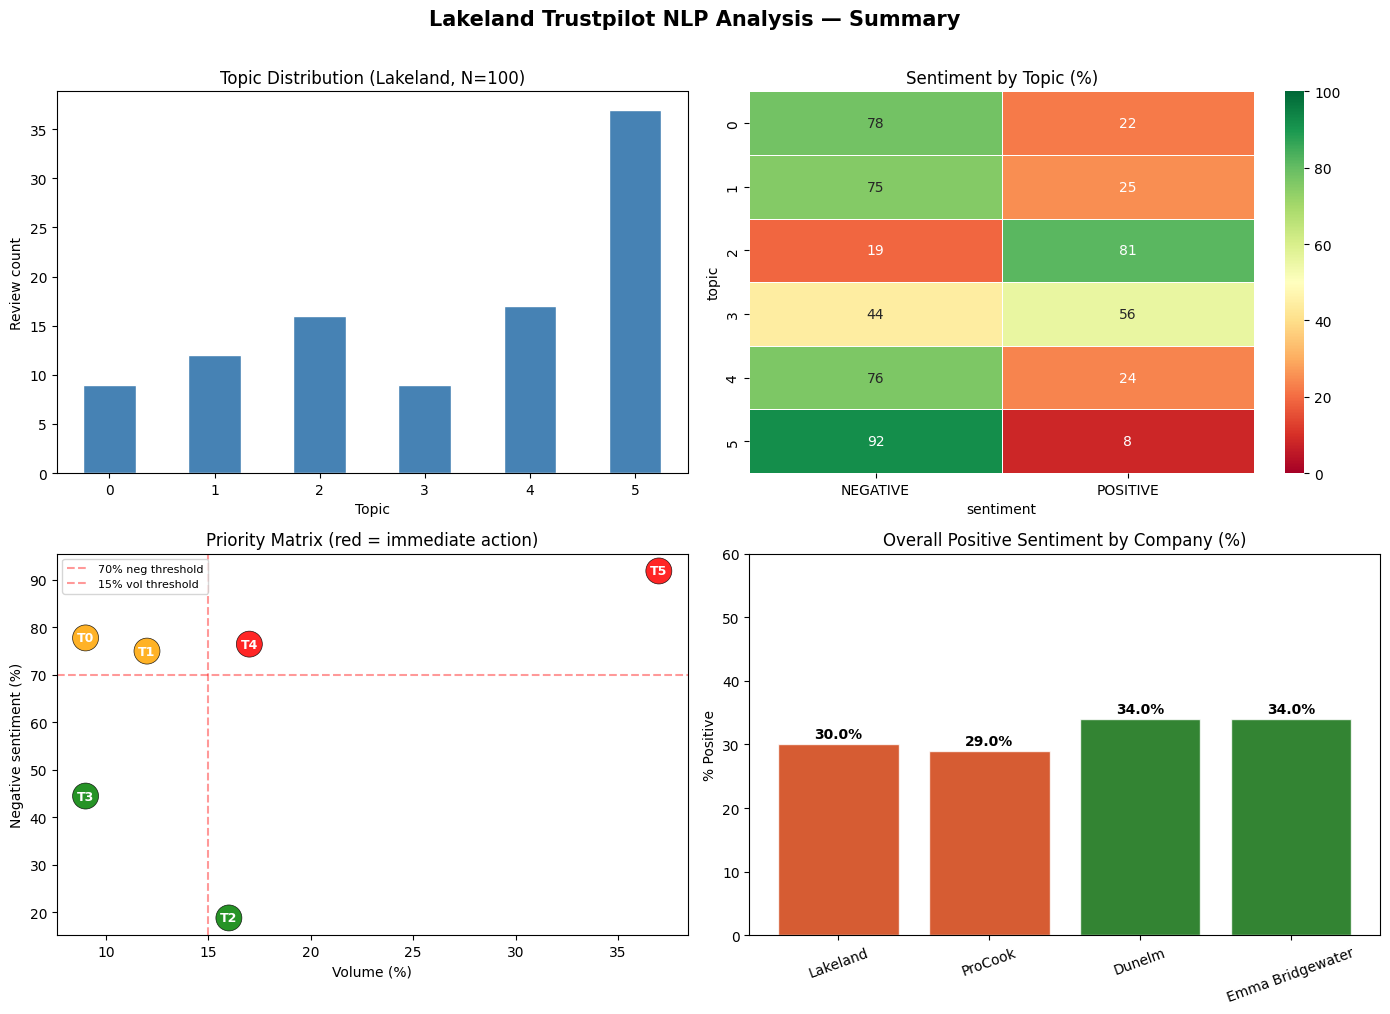

Saved: lakeland_analysis.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lakeland Trustpilot NLP Analysis — Summary', fontsize=15, fontweight='bold', y=1.01)

# 1. Topic distribution
topic_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Topic Distribution (Lakeland, N=100)')
axes[0, 0].set_xlabel('Topic')
axes[0, 0].set_ylabel('Review count')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Sentiment heatmap
sns.heatmap(topic_sent_pct, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=axes[0, 1], vmin=0, vmax=100, linewidths=0.5)
axes[0, 1].set_title('Sentiment by Topic (%)')

# 3. Priority matrix
volumes      = [topic_counts.get(t, 0) / len(target_df) * 100 for t in range(6)]
negativities = [topic_sent_pct.loc[t, 'NEGATIVE'] if t in topic_sent_pct.index else 0 for t in range(6)]
pt_colors    = ['red' if (n > 70 and v > 15) else 'orange' if n > 70 else 'green'
                for v, n in zip(volumes, negativities)]

axes[1, 0].scatter(volumes, negativities, s=350, c=pt_colors, alpha=0.85, edgecolors='black', linewidths=0.5)
for i, (v, n) in enumerate(zip(volumes, negativities)):
    axes[1, 0].annotate(f'T{i}', (v, n), ha='center', va='center',
                        fontsize=9, fontweight='bold', color='white')
axes[1, 0].axhline(y=70, color='red', linestyle='--', alpha=0.4, label='70% neg threshold')
axes[1, 0].axvline(x=15, color='red', linestyle='--', alpha=0.4, label='15% vol threshold')
axes[1, 0].set_xlabel('Volume (%)')
axes[1, 0].set_ylabel('Negative sentiment (%)')
axes[1, 0].set_title('Priority Matrix (red = immediate action)')
axes[1, 0].legend(fontsize=8)

# 4. Competitor comparison
comp_names  = list(companies.keys())
comp_scores = [lakeland_pos] + [comp_results[v]['pos_pct'] for v in list(companies.values())[1:]]
bar_colors  = ['#cc3300' if s < 32 else '#006600' for s in comp_scores]
bars = axes[1, 1].bar(comp_names, comp_scores, color=bar_colors, alpha=0.8, edgecolor='white')
for bar, score in zip(bars, comp_scores):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{score:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1, 1].set_title('Overall Positive Sentiment by Company (%)')
axes[1, 1].set_ylabel('% Positive')
axes[1, 1].set_ylim(0, 60)
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('lakeland_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lakeland_analysis.png')

---
## Section 10 — Conclusions & Recommendations

### Q1 — Overall Sentiment

Lakeland's NLP model classifies **70% of reviews as negative and 30% as positive**. This is not visible from star ratings alone (which are artificially balanced at 20 reviews per star level).

In the competitive comparison:

| Company | Positive % | vs Lakeland |
|---------|-----------|-------------|
| Emma Bridgewater | 34% | +4 pp |
| Dunelm | 34% | +4 pp |
| **Lakeland** | **30%** | baseline |
| ProCook | 29% | −1 pp |

Lakeland trails the sector leaders (Dunelm, Emma Bridgewater) by **4 percentage points** and is broadly level with ProCook.

---

### Q2 — Topics Identified

LDA identified 6 themes across the Home & Garden sector. Applied to Lakeland's 100 reviews, the distribution is:

| Topic | Key words | Lakeland share |
|-------|-----------|----------------|
| T5    | order, customer, service, received | ~37% |
| T4    | quality, bought, product, shed | ~17% |
| T2    | service, helpful, kitchen, great | ~16% |
| T1    | delivery, delivered, time, good | ~12% |
| T0    | delivery, day, told, days | ~9% |
| T3    | good, quality, great, service | ~9% |

Topic T5 (order processing and customer service interactions) dominates at **37% of all reviews** — more than double the next largest topic. All competitors discuss similar themes, confirming this is a sector-wide pattern rather than a Lakeland-specific problem.

---

### Q3 — Sentiment by Topic & Competitive Comparison

| Topic | Lakeland neg% | Comp avg neg% | Gap | Assessment |
|-------|--------------|---------------|-----|------------|
| T5 (order/service) | 91.9% | 94.2% | −2.3 pp | Industry-wide problem; Lakeland **slightly better** |
| T4 (product quality) | 76.5% | 82.2% | −5.7 pp | Lakeland **stronger** than competitors |
| T2 (in-store/kitchen) | 18.8% | 23.0% | −4.3 pp | **Key strength** — best-in-class |
| T1 (delivery) | 75.0% | 66.9% | +8.1 pp | Lakeland **worse** than competitors |
| T0 (delivery delays) | 77.8% | 78.7% | −0.9 pp | Similar to sector |
| T3 (general quality) | 44.4% | 35.8% | +8.6 pp | Lakeland **somewhat worse** |

The analysis reveals a more nuanced picture than expected. Lakeland is not categorically worse than competitors — on the largest topic (T5) and on product/kitchen topics, it performs comparably or better. The two areas where Lakeland underperforms are delivery (T1) and general quality mentions (T3).

---

### Q4 — Areas for Improvement

**Priority 1 — Reduce the volume of order/service complaints (T5)**  
Topic T5 accounts for 37% of all reviews and 91.9% are negative — the single largest driver of dissatisfied customers. Although competitor sentiment on this topic is also poor (~94%), the volume at Lakeland is the controllable lever. Reducing the number of customers who feel compelled to write about order problems is the highest-impact action.
- Actions: proactive order confirmation, real-time delivery tracking, faster escalation paths  
- Expected impact: reduces T5 review share from 37% toward ~25%, improving overall sentiment

**Priority 2 — Improve delivery experience (T1)**  
Topic T1 (delivery) is the one area where Lakeland is measurably worse than competitors (+8.1 pp negative gap). This is an operational issue that competitors are managing more effectively.
- Actions: review courier partnerships, offer premium/tracked delivery, improve packaging  
- Expected impact: closes the 8 pp delivery sentiment gap

**Maintain and leverage strength — In-store and kitchen experience (T2)**  
Topic T2 is Lakeland's clear competitive advantage: only 18.8% negative vs 23.0% for competitors. This reflects positively on staff, product range, and the in-store/brand experience.
- Actions: showcase this in marketing, build brand positioning around quality and service  
- Expected impact: differentiates Lakeland from ProCook and Dunelm in a crowded market

---

### Business Impact Summary

| Metric | Current | Target (6 months) | Path |
|--------|---------|-------------------|------|
| Overall positive sentiment | 30% | 36–38% | Reduce T5 volume + close T1 gap |
| T5 review share | 37% | ~25% | Fewer customers needing to complain |
| T1 negativity gap vs competitors | +8.1 pp | 0 pp | Match competitor delivery performance |
| vs sector leaders (Dunelm/Emma B) | −4 pp | On par | Combined T5 + T1 improvements |